## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Aprendizaje Automático
**Proyecto Final:** Predicción de Precio de Renta en Airbnb

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

---

**Objetivo:** Construir un modelo predictivo que estime el precio de renta por noche adecuado para el departamento de Gabriela en Coyoacán, CDMX (2 habitaciones, internet, TV y estacionamiento), usando técnicas de aprendizaje automático. Se compararán tres modelos basados en árboles (Árbol de Decisión, Random Forest y Gradient Boosting), se aplicará reducción de dimensionalidad por selección de variables y PCA, y se justificará el precio recomendado con base en los resultados.

### 1. Importar librerías y leer el dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Cargar el dataset
df = pd.read_csv('AirbnbMexico.csv')
print('Registros totales: ', df.shape[0])
print('Variables: ', df.shape[1])

Registros totales:  27051
Variables:  79


In [3]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20250927041820,2025-09-27,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Shopping Mall, Interlomas Park and th...",https://a0.muscache.com/pictures/f395ab78-1185...,153786,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
1,44616,https://www.airbnb.com/rooms/44616,20250927041820,2025-09-28,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,NaN,https://a0.muscache.com/pictures/251410/ec75fe...,196253,...,4.78,4.98,4.47,NaN,f,9,4,2,0,0.38
2,56074,https://www.airbnb.com/rooms/56074,20250927041820,2025-09-28,city scrape,Great space in historical San Rafael,This great apartment is located in one of the ...,Very traditional neighborhood with all service...,https://a0.muscache.com/pictures/3005118/60dac...,265650,...,4.94,4.76,4.79,NaN,f,1,1,0,0,0.48
3,67703,https://www.airbnb.com/rooms/67703,20250927041820,2025-09-28,previous scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",NaN,https://a0.muscache.com/pictures/3281720/6f078...,334451,...,4.92,4.98,4.92,NaN,f,2,2,0,0,0.30
4,70644,https://www.airbnb.com/rooms/70644,20250927041820,2025-09-28,previous scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,https://a0.muscache.com/pictures/f397d2da-d045...,212109,...,4.98,4.96,4.92,NaN,f,3,2,1,0,0.81


In [4]:
# Observamos las columnas existentes
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

### 2. Preprocesamiento de datos

Antes de entrenar cualquier modelo es necesario limpiar los datos. Aquí hacemos tres cosas principales:
1. Limpieza del precio: viene como texto con formato `$1,234.00`, lo convertimos a número.
2. Revisar si existen ids duplicados.
3. Selección de variables relevantes: descartamos columnas que no aportan información útil (URLs, textos largos, identificadores).

In [5]:
# Limpiar la columna de precio: quitar $, comas y convertir a float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Revisar si existen ids duplicados
print('Registros duplicados: ', df.duplicated(subset=['id']).sum())

# Revisar cuántos nulos tiene price
print('Nulos en price:', df['price'].isnull().sum())

# Eliminar filas sin precio
df = df.dropna(subset=['price'])
print('Registros con precio disponible: ', len(df))

Registros duplicados:  0
Nulos en price: 3484
Registros con precio disponible:  23567


In [6]:
# Eliminar precios extremos: precio < 100 o > 10000 pesos por noche
df = df[(df['price'] >= 100) & (df['price'] <= 10000)]
print('Registros tras filtrar outliers de precio:', len(df))
print()
print('Estadísticas de precio (MXN por noche):')
print(df['price'].describe().round(2))

Registros tras filtrar outliers de precio: 23330

Estadísticas de precio (MXN por noche):
count    23330.00
mean      1338.19
std       1168.71
min        127.00
25%        640.00
50%       1031.00
75%       1583.00
max      10000.00
Name: price, dtype: float64


In [7]:
# Seleccionamos las variables que tienen sentido para predecir el precio
# y que están disponibles antes de publicar un listing
features = [
    'neighbourhood_cleansed',        # Alcaldía (zona geográfica)
    'room_type',                     # Tipo de cuarto
    'property_type',                 # Tipo de propiedad
    'accommodates',                  # Capacidad (personas)
    'bedrooms',                      # Habitaciones
    'beds',                          # Camas
    'bathrooms',                     # Baños
    'minimum_nights',                # Noches mínimas de estancia
    'host_is_superhost',             # Es superanfitrión?
    'host_identity_verified',        # Identidad verificada?
    'instant_bookable',              # Reserva instantánea?
    'review_scores_rating',          # Calificación general
    'review_scores_cleanliness',     # Limpieza
    'review_scores_location',        # Ubicación
    'number_of_reviews',             # Número de reseñas
    'reviews_per_month',             # Frecuencia de reseñas
    'availability_365',              # Días disponibles al año
    'calculated_host_listings_count' # Número de listings del anfitrión
]

df_model = df[features + ['price']].copy()
print('Variables seleccionadas:', len(features))
print('\nNulos por columna:')
print(df_model.isnull().sum())

Variables seleccionadas: 18

Nulos por columna:
neighbourhood_cleansed               0
room_type                            0
property_type                        0
accommodates                         0
bedrooms                            98
beds                                21
bathrooms                           12
minimum_nights                       0
host_is_superhost                 1486
host_identity_verified               2
instant_bookable                     0
review_scores_rating              2454
review_scores_cleanliness         2455
review_scores_location            2455
number_of_reviews                    0
reviews_per_month                 2454
availability_365                     0
calculated_host_listings_count       0
price                                0
dtype: int64


#### Tratamiento de valores faltantes y codificación de variables categóricas

In [8]:
# Rellenar nulos numéricos con la mediana (más robusta que la media ante outliers)
num_cols = ['bedrooms', 'beds', 'bathrooms', 'review_scores_rating',
            'review_scores_cleanliness', 'review_scores_location', 'reviews_per_month']
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Variables binarias: convertir a 0/1
bool_cols = ['host_is_superhost', 'host_identity_verified', 'instant_bookable']
for col in bool_cols:
    df_model[col] = df_model[col].map({'t': 1, 'f': 0, True: 1, False: 0}).fillna(0)

# Variables categóricas: codificación con LabelEncoder
cat_cols = ['neighbourhood_cleansed', 'room_type', 'property_type']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print('Preprocesamiento completado. Shape final:', df_model.shape)
print('Nulos restantes:', df_model.isnull().sum().sum())

Preprocesamiento completado. Shape final: (23330, 19)
Nulos restantes: 0


### 3. Análisis exploratorio y visualizaciones

Antes de entrenar modelos, es importante entender los datos. Vemos la distribución de precios y cómo varía según las características más importantes.

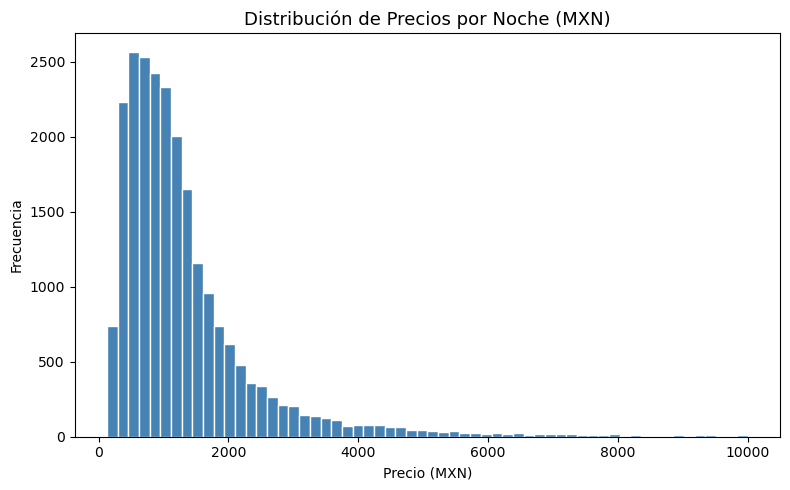

In [9]:
# Distribución del precio
plt.figure(figsize=(8, 5))
plt.hist(df_model['price'], bins=60, color='steelblue', edgecolor='white')
plt.title('Distribución de Precios por Noche (MXN)', fontsize=13)
plt.xlabel('Precio (MXN)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

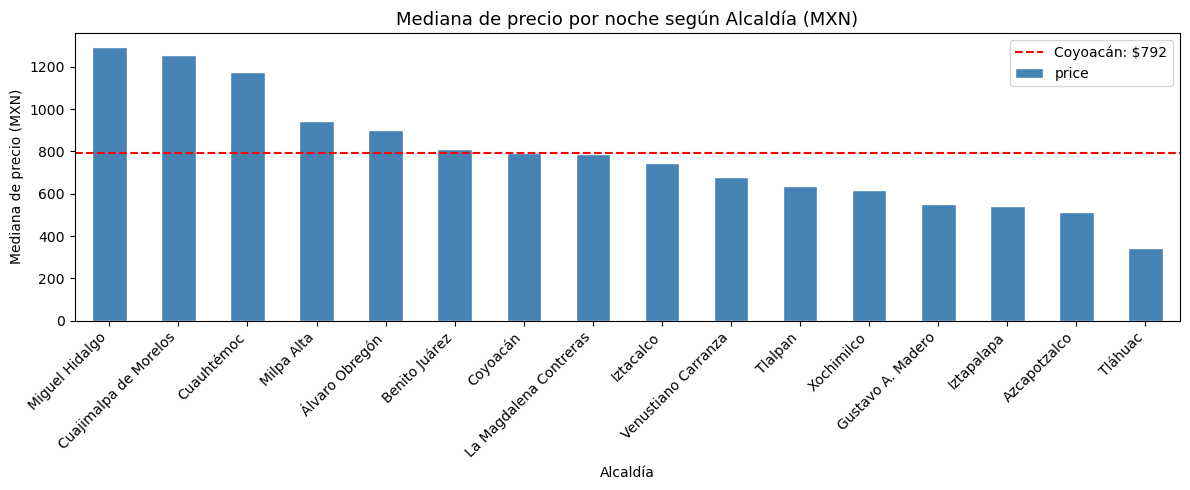

Mediana precio en Coyoacán: $792 MXN/noche


In [10]:
# Mediana de precio por alcaldía
precio_alcaldia = df.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
precio_alcaldia.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Mediana de precio por noche según Alcaldía (MXN)', fontsize=13)
plt.xlabel('Alcaldía')
plt.ylabel('Mediana de precio (MXN)')
plt.xticks(rotation=45, ha='right')
coy_precio = precio_alcaldia['Coyoacán']
plt.axhline(coy_precio, color='red', linestyle='--', label=f'Coyoacán: ${coy_precio:.0f}')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Mediana precio en Coyoacán: ${coy_precio:.0f} MXN/noche')

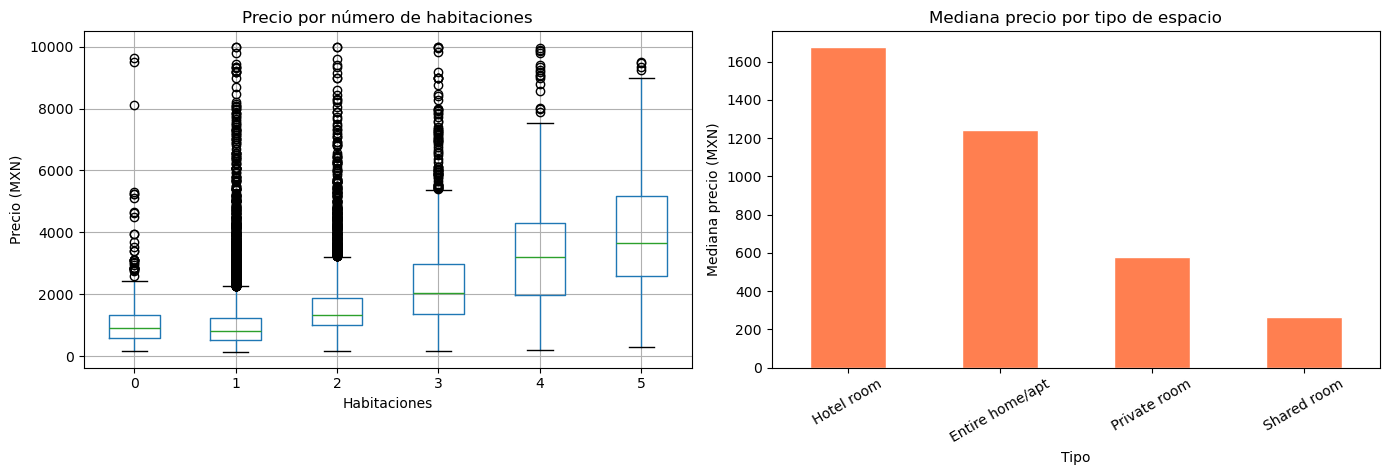

In [11]:
# Precio según número de habitaciones y tipo de cuarto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_box = df[df['bedrooms'].between(0, 5)].copy()
df_box['bedrooms'] = df_box['bedrooms'].astype(int)
df_box.boxplot(column='price', by='bedrooms', ax=axes[0])
axes[0].set_title('Precio por número de habitaciones')
axes[0].set_xlabel('Habitaciones')
axes[0].set_ylabel('Precio (MXN)')
plt.sca(axes[0])
plt.suptitle('')

df_rt = df.groupby('room_type')['price'].median().sort_values(ascending=False)
df_rt.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Mediana precio por tipo de espacio')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Mediana precio (MXN)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Matriz de correlación

Identificar las variables más correlacionadas con `price`

In [12]:
# Correlación de cada variable con el precio
correlaciones = df_model.corr()['price'].drop('price').sort_values(key=abs, ascending=False)
print('Correlación de cada variable con el precio (valor absoluto):')
print(correlaciones.round(3))

Correlación de cada variable con el precio (valor absoluto):
accommodates                      0.507
bedrooms                          0.435
bathrooms                         0.383
beds                              0.373
room_type                        -0.306
property_type                    -0.252
calculated_host_listings_count    0.112
review_scores_location            0.106
review_scores_cleanliness         0.097
instant_bookable                  0.088
review_scores_rating              0.078
host_is_superhost                 0.069
number_of_reviews                -0.042
minimum_nights                    0.042
reviews_per_month                -0.028
availability_365                 -0.015
neighbourhood_cleansed            0.013
host_identity_verified            0.003
Name: price, dtype: float64


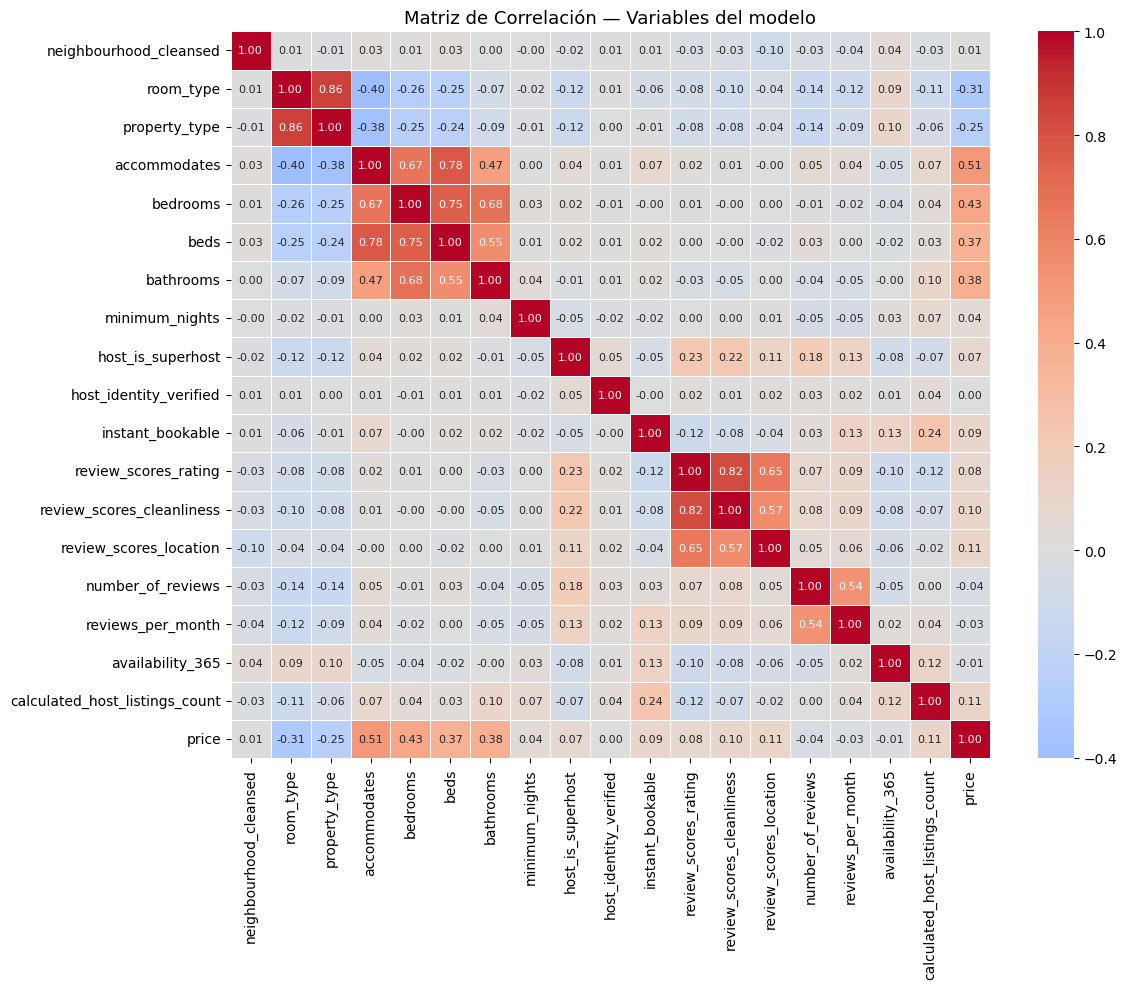

In [13]:
# Heatmap de correlaciones
plt.figure(figsize=(12, 10))
corr_matrix = df_model.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Variables del modelo', fontsize=13)
plt.tight_layout()
plt.show()

### 4. Dividir los datos: X (variables de entrada) y y (variable de salida: price)

La variable de salida es el precio directamente en MXN por noche.

In [14]:
X = df_model.drop(columns=['price'])
y = df_model['price']

print('Variables de entrada (X):', X.shape)
print('Variable de salida (y):', y.shape)

Variables de entrada (X): (23330, 18)
Variable de salida (y): (23330,)


### 5. Dividir aleatoriamente: 70% entrenamiento y 30% prueba

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (16331, 18)
Prueba: (6999, 18)


### 6. Modelo 1: Árbol de Decisión (línea base)

Comenzamos con un árbol de decisión simple. Esto nos da una línea base para comparar con los modelos más complejos. Usamos `max_depth=8` para controlar el sobreajuste.

In [16]:
tree = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)

In [17]:
y_pred_tree = tree.predict(X_test)

r2_tree   = r2_score(y_test, y_pred_tree)
mae_tree  = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print('Árbol de Decisión')
print(f'R²:   {r2_tree:.4f}')
print(f'MAE:  ${mae_tree:.2f} MXN')
print(f'RMSE: ${rmse_tree:.2f} MXN')

Árbol de Decisión
R²:   0.4190
MAE:  $513.43 MXN
RMSE: $875.37 MXN


Medimos qué tan bien le fue al modelo. R² nos dice qué porcentaje de la variación en el precio logra explicar el modelo (entre más cercano a 1, mejor). MAE nos dice cuánto se equivoca el modelo en promedio. El RMSE te dice el error promedio del modelo, pero penalizando más los errores grandes.


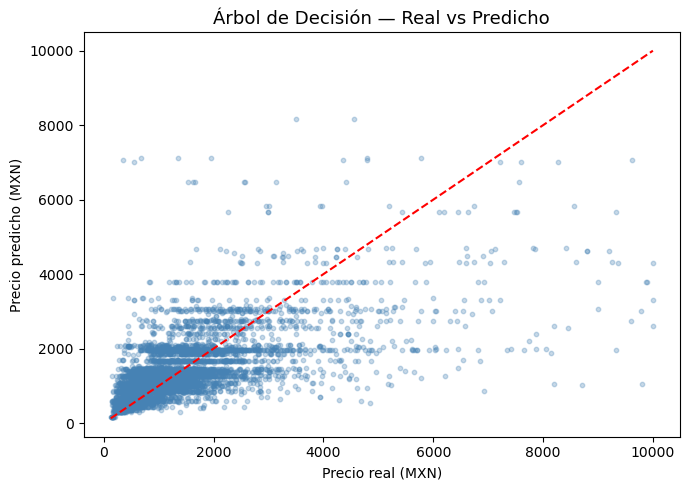

In [18]:
# Gráfica de dispersión: valores reales vs predichos
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_tree, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Árbol de Decisión — Real vs Predicho', fontsize=13)
plt.xlabel('Precio real (MXN)')
plt.ylabel('Precio predicho (MXN)')
plt.tight_layout()
plt.show()

¿Por qué hay puntos arriba y abajo de la línea roja?
* Puntos arriba de la línea: el modelo predijo un valor más alto que el precio real, es decir, sobreestimó.
* Puntos abajo de la línea: el modelo predijo un valor más bajo que el precio real, es decir, subestimó.

### Importancia de variables (Árbol de Decisión)

Vemos cuáles variables fueron las más útiles para que el árbol tomara decisiones. Entre más grande el valor, más importante fue esa variable para predecir el precio.

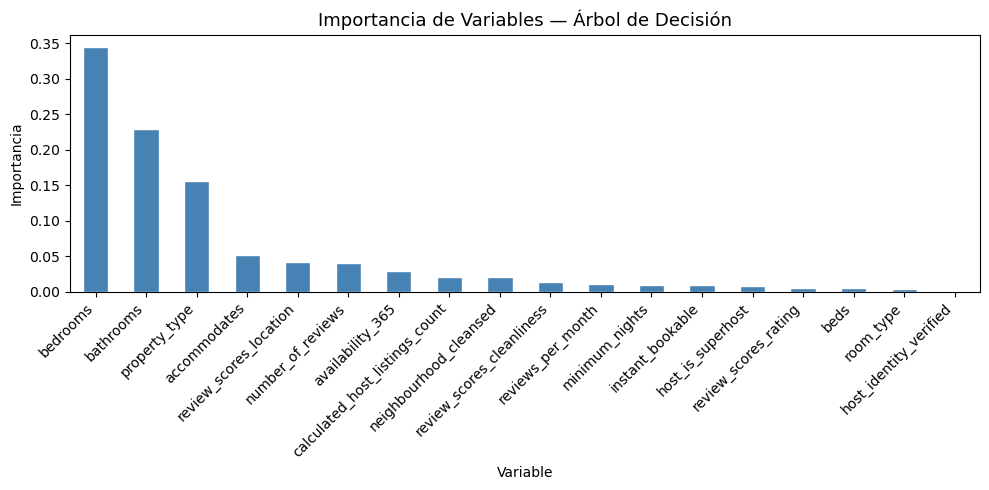

In [19]:
importancias_tree = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias_tree.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importancia de Variables — Árbol de Decisión', fontsize=13)
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Modelo 2: Random Forest

Repetimos los pasos 4, 5 y 6 usando RandomForestRegressor. En lugar de un solo árbol, este modelo entrena muchos árboles distintos y promedia sus predicciones. Así reduce los errores y generalmente da mejores resultados.

In [20]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [21]:
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('Random Forest')
print(f'R²:   {r2_rf:.4f}')
print(f'MAE:  ${mae_rf:.2f} MXN')
print(f'RMSE: ${rmse_rf:.2f} MXN')

Random Forest
R²:   0.5372
MAE:  $454.37 MXN
RMSE: $781.29 MXN


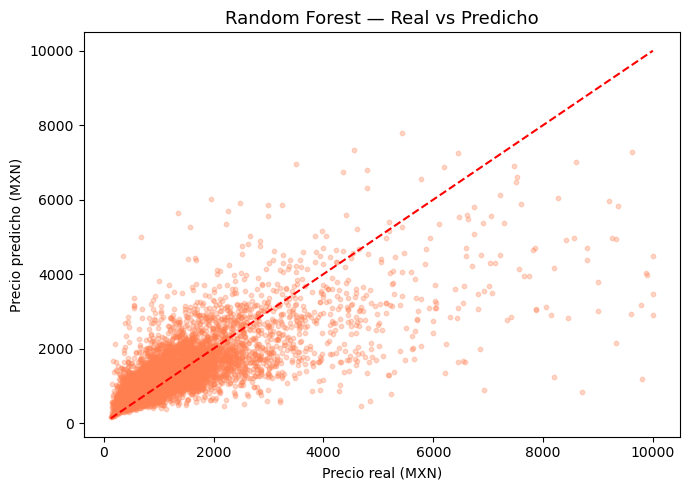

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='coral', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Random Forest — Real vs Predicho', fontsize=13)
plt.xlabel('Precio real (MXN)')
plt.ylabel('Precio predicho (MXN)')
plt.tight_layout()
plt.show()

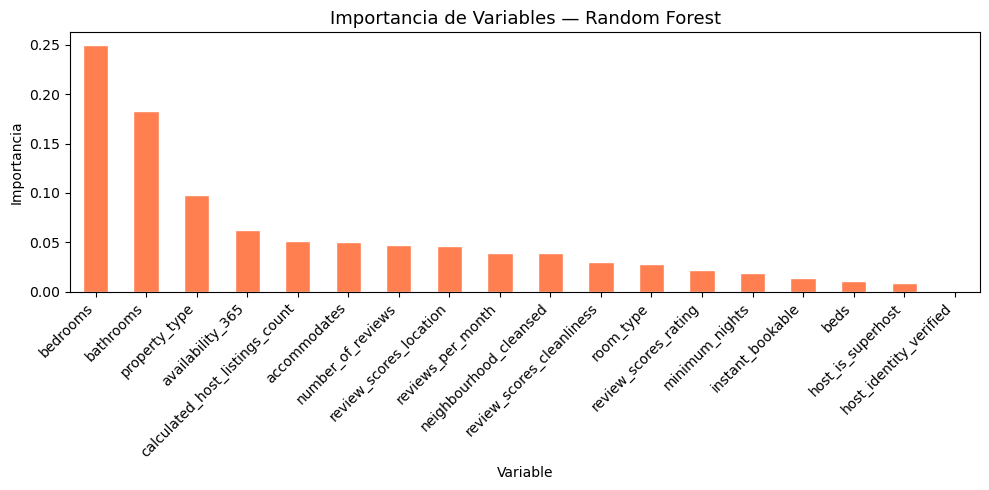

Top 5 variables más importantes (Random Forest):
bedrooms                          0.2502
bathrooms                         0.1832
property_type                     0.0978
availability_365                  0.0622
calculated_host_listings_count    0.0511
dtype: float64


In [23]:
importancias_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias_rf.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Importancia de Variables — Random Forest', fontsize=13)
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 variables más importantes (Random Forest):')
print(importancias_rf.head(5).round(4))

## 8. Modelo 3: Gradient Boosting

El Gradient Boosting también es un ensamble de árboles, pero los construye de forma secuencial: cada árbol nuevo intenta corregir los errores del árbol anterior. Esto generalmente da mejores resultados que Random Forest, aunque tarda más en entrenarse.

In [24]:
gb = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                               min_samples_leaf=10, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=10,
                          n_estimators=300, random_state=42)

In [25]:
y_pred_gb = gb.predict(X_test)

r2_gb   = r2_score(y_test, y_pred_gb)
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print('Gradient Boosting')
print(f'R²:   {r2_gb:.4f}')
print(f'MAE:  ${mae_gb:.2f} MXN')
print(f'RMSE: ${rmse_gb:.2f} MXN')

Gradient Boosting
R²:   0.5621
MAE:  $448.54 MXN
RMSE: $760.01 MXN


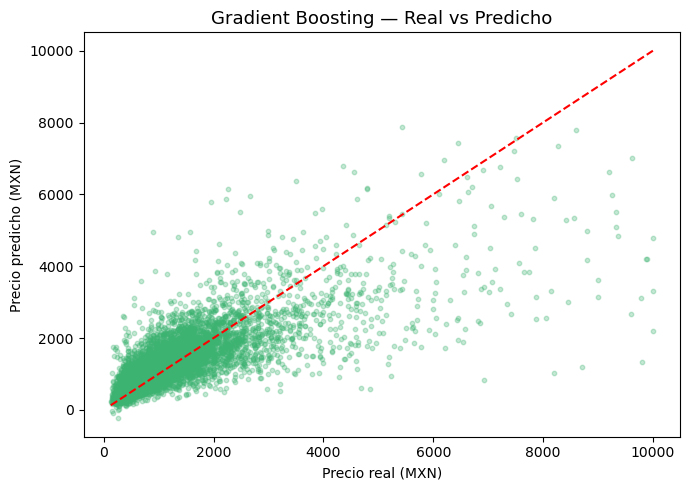

In [26]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_gb, alpha=0.3, color='mediumseagreen', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Gradient Boosting — Real vs Predicho', fontsize=13)
plt.xlabel('Precio real (MXN)')
plt.ylabel('Precio predicho (MXN)')
plt.tight_layout()
plt.show()

Comparamos los resultados de los tres modelos para ver cuál predice mejor el precio.

In [27]:
resultados = pd.DataFrame({
    'Modelo':      ['Árbol de Decisión', 'Random Forest', 'Gradient Boosting'],
    'R²':          [r2_tree,   r2_rf,   r2_gb],
    'MAE (MXN)':   [mae_tree,  mae_rf,  mae_gb],
    'RMSE (MXN)':  [rmse_tree, rmse_rf, rmse_gb]
})
resultados = resultados.sort_values('R²', ascending=False).reset_index(drop=True)
resultados

,Modelo,R²,MAE (MXN),RMSE (MXN)
0,Gradient Boosting,0.562051,448.540344,760.011406
1,Random Forest,0.537182,454.367661,781.291910
2,Árbol de Decisión,0.419013,513.428275,875.369267


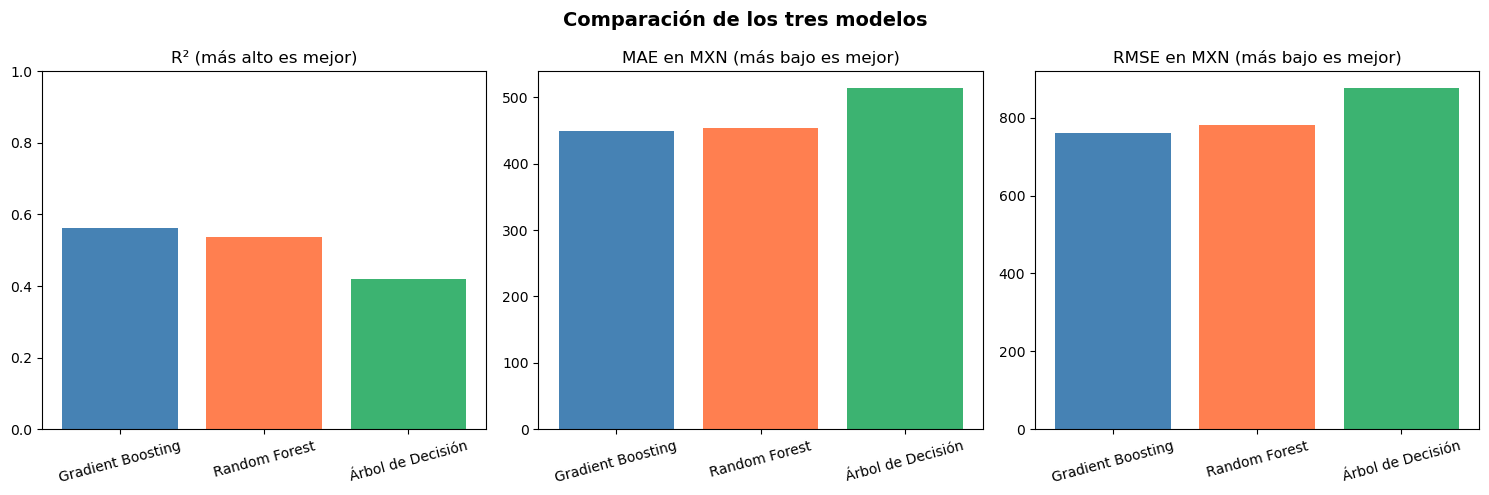

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = ['steelblue', 'coral', 'mediumseagreen']

axes[0].bar(resultados['Modelo'], resultados['R²'], color=colores)
axes[0].set_title('R² (más alto es mejor)', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(resultados['Modelo'], resultados['MAE (MXN)'], color=colores)
axes[1].set_title('MAE en MXN (más bajo es mejor)', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(resultados['Modelo'], resultados['RMSE (MXN)'], color=colores)
axes[2].set_title('RMSE en MXN (más bajo es mejor)', fontsize=12)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de los tres modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Reducción de Dimensionalidad

Analizamos si podemos obtener un modelo igual de bueno usando menos variables. Comparamos tres estrategias: selección por correlación con el precio, selección por Feature Importance y PCA (Análisis de Componentes Principales). Las dos primeras se aplican únicamente con Random Forest; PCA se aplica a los tres algoritmos para medir su impacto en cada uno.

#### Identificar las 5 variables más correlacionadas con `price`

In [29]:
top5_corr = correlaciones.abs().sort_values(ascending=False).head(5).index.tolist()
print('5 variables más correlacionadas con el precio:')
print(top5_corr)

5 variables más correlacionadas con el precio:
['accommodates', 'bedrooms', 'bathrooms', 'beds', 'room_type']


In [30]:
# Modelo B: Random Forest con las 5 variables más correlacionadas
X_train_corr = X_train[top5_corr]
X_test_corr = X_test[top5_corr]

rf_corr = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                                random_state=42, n_jobs=-1)
rf_corr.fit(X_train_corr, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [31]:
y_pred_corr = rf_corr.predict(X_test_corr)

r2_corr   = r2_score(y_test, y_pred_corr)
mae_corr  = mean_absolute_error(y_test, y_pred_corr)
rmse_corr = np.sqrt(mean_squared_error(y_test, y_pred_corr))

print('RF con 5 variables por correlación')
print(f'R²:   {r2_corr:.4f}')
print(f'MAE:  ${mae_corr:.2f} MXN')
print(f'RMSE: ${rmse_corr:.2f} MXN')

RF con 5 variables por correlación
R²:   0.3627
MAE:  $550.88 MXN
RMSE: $916.81 MXN


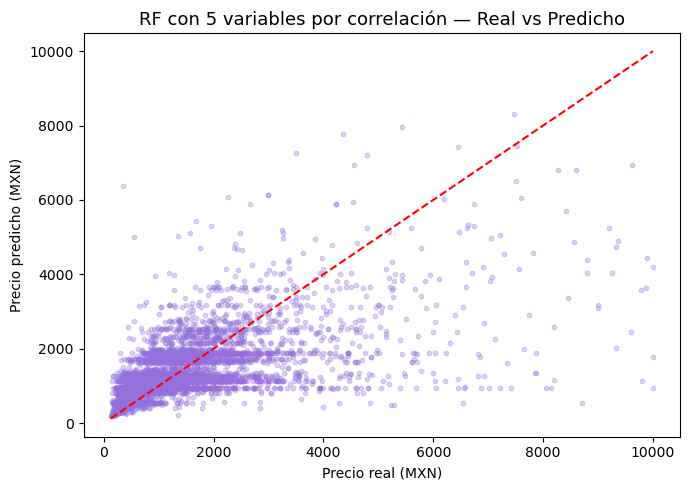

In [32]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_corr, alpha=0.3, color='mediumpurple', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('RF con 5 variables por correlación — Real vs Predicho', fontsize=13)
plt.xlabel('Precio real (MXN)')
plt.ylabel('Precio predicho (MXN)')
plt.tight_layout()
plt.show()

#### Modelo C: Random Forest con las 5 variables de mayor Feature Importance

In [33]:
top5_imp = importancias_rf.head(5).index.tolist()
print('5 variables de mayor importancia (Random Forest):')
print(top5_imp)

5 variables de mayor importancia (Random Forest):
['bedrooms', 'bathrooms', 'property_type', 'availability_365', 'calculated_host_listings_count']


In [34]:
X_train_imp = X_train[top5_imp]
X_test_imp  = X_test[top5_imp]

rf_imp = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                               random_state=42, n_jobs=-1)
rf_imp.fit(X_train_imp, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [35]:
y_pred_imp = rf_imp.predict(X_test_imp)

r2_imp   = r2_score(y_test, y_pred_imp)
mae_imp  = mean_absolute_error(y_test, y_pred_imp)
rmse_imp = np.sqrt(mean_squared_error(y_test, y_pred_imp))

print('RF con 5 variables por Feature Importance')
print(f'R²:   {r2_imp:.4f}')
print(f'MAE:  ${mae_imp:.2f} MXN')
print(f'RMSE: ${rmse_imp:.2f} MXN')

RF con 5 variables por Feature Importance
R²:   0.4513
MAE:  $505.16 MXN
RMSE: $850.74 MXN


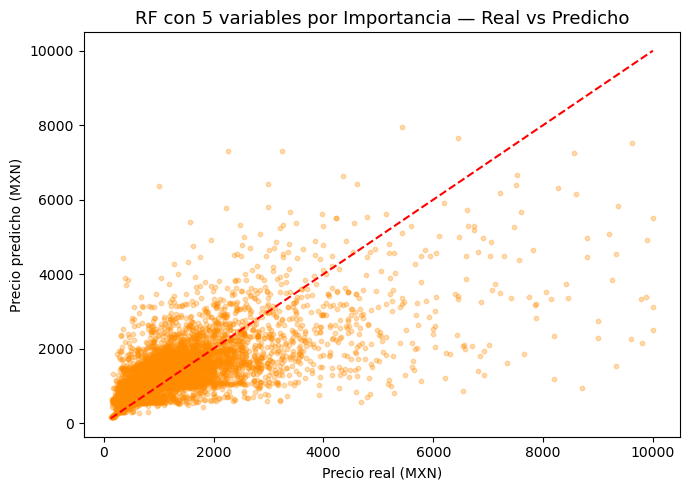

In [36]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_imp, alpha=0.3, color='darkorange', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('RF con 5 variables por Importancia — Real vs Predicho', fontsize=13)
plt.xlabel('Precio real (MXN)')
plt.ylabel('Precio predicho (MXN)')
plt.tight_layout()
plt.show()

### Comparación de los tres modelos de reducción de dimensionalidad

In [37]:
resultados_dim = pd.DataFrame({
    'Modelo':     ['RF — Todas las variables', 'RF — 5 por correlación', 'RF — 5 por importancia'],
    'R²':         [r2_rf,   r2_corr,   r2_imp],
    'MAE (MXN)':  [mae_rf,  mae_corr,  mae_imp],
    'RMSE (MXN)': [rmse_rf, rmse_corr, rmse_imp]
})
resultados_dim = resultados_dim.sort_values('R²', ascending=False).reset_index(drop=True)
resultados_dim

,Modelo,R²,MAE (MXN),RMSE (MXN)
0,RF — Todas las variables,0.537182,454.367661,781.291910
1,RF — 5 por importancia,0.451253,505.156940,850.735111
2,RF — 5 por correlación,0.362707,550.878460,916.806576


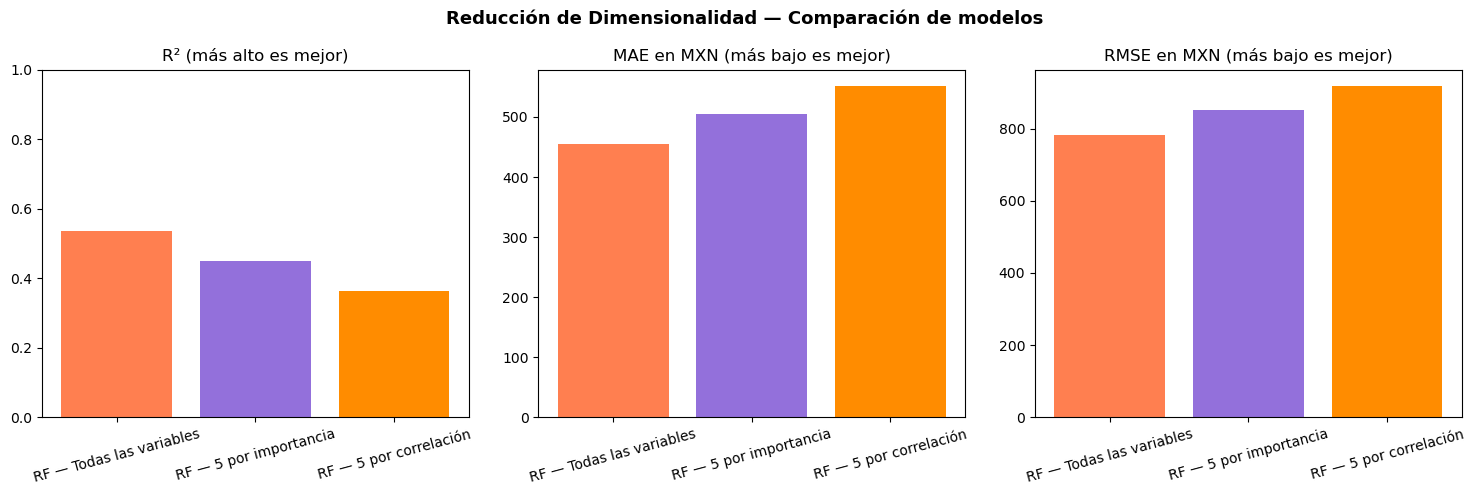

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores_dim = ['coral', 'mediumpurple', 'darkorange']

axes[0].bar(resultados_dim['Modelo'], resultados_dim['R²'], color=colores_dim)
axes[0].set_title('R² (más alto es mejor)', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(resultados_dim['Modelo'], resultados_dim['MAE (MXN)'], color=colores_dim)
axes[1].set_title('MAE en MXN (más bajo es mejor)', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(resultados_dim['Modelo'], resultados_dim['RMSE (MXN)'], color=colores_dim)
axes[2].set_title('RMSE en MXN (más bajo es mejor)', fontsize=12)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Reducción de Dimensionalidad — Comparación de modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Modelo D: Árbol de Decisión, Random Forest y Gradient Boosting con PCA

Aplicamos PCA a los tres algoritmos para comparar el impacto de la reducción en cada uno. Primero escalamos y calculamos cuántas componentes retienen el 80% de la varianza, luego entrenamos los tres modelos sobre ese espacio reducido.

In [39]:
# PCA requiere escalar primero (media 0, desviación estándar 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# PCA con todas las componentes para analizar la varianza
pca_full = PCA()
pca_full.fit(X_train_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_80 = int(np.argmax(varianza_acumulada >= 0.80)) + 1

print(f'Total de componentes: {len(pca_full.explained_variance_ratio_)}')
print(f'Componentes necesarias para el 80% de varianza: {n_componentes_80}')
print(f'Con 2 componentes se explica el: {varianza_acumulada[1]*100:.2f}% de la varianza')

Total de componentes: 18
Componentes necesarias para el 80% de varianza: 10
Con 2 componentes se explica el: 33.03% de la varianza


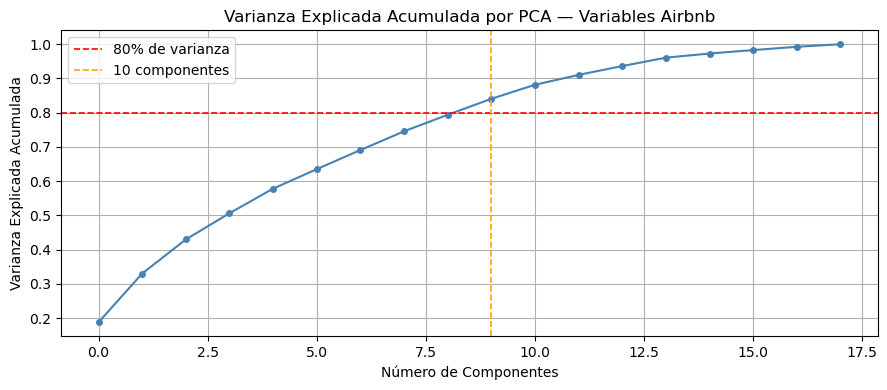

In [40]:
plt.figure(figsize=(9, 4))
plt.plot(varianza_acumulada, marker='o', markersize=4, color='steelblue')
plt.axhline(y=0.80, color='red', linestyle='--', linewidth=1.2, label='80% de varianza')
plt.axvline(x=n_componentes_80 - 1, color='orange', linestyle='--', linewidth=1.2,
            label=f'{n_componentes_80} componentes')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por PCA — Variables Airbnb')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observaciones:**

* Se necesitan **10 componentes** para retener el 80% de la varianza de las 18 variables originales.
* Esto significa que pasamos de 18 dimensiones a 10 sin perder información relevante.
* Aplicamos esas mismas 10 componentes a los tres modelos.

In [41]:
# Aplicamos PCA con las componentes que explican el 80% de la varianza
pca = PCA(n_components=n_componentes_80)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Dimensiones originales:  {X_train.shape[1]} variables')
print(f'Dimensiones con PCA:     {X_train_pca.shape[1]} componentes')
print(f'Varianza retenida:       {pca.explained_variance_ratio_.sum()*100:.1f}%')

Dimensiones originales:  18 variables
Dimensiones con PCA:     10 componentes
Varianza retenida:       84.1%


In [42]:
tree_pca = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
tree_pca.fit(X_train_pca, y_train)
y_pred_tree_pca = tree_pca.predict(X_test_pca)

r2_tree_pca   = r2_score(y_test, y_pred_tree_pca)
mae_tree_pca  = mean_absolute_error(y_test, y_pred_tree_pca)
rmse_tree_pca = np.sqrt(mean_squared_error(y_test, y_pred_tree_pca))

print(f'Árbol de Decisión + PCA ({n_componentes_80} componentes)')
print(f'R²:   {r2_tree_pca:.4f}')
print(f'MAE:  ${mae_tree_pca:.2f} MXN')
print(f'RMSE: ${rmse_tree_pca:.2f} MXN')

Árbol de Decisión + PCA (10 componentes)
R²:   0.2832
MAE:  $574.11 MXN
RMSE: $972.34 MXN


#### Random Forest con PCA

In [43]:
rf_pca = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                               random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)

r2_rf_pca   = r2_score(y_test, y_pred_rf_pca)
mae_rf_pca  = mean_absolute_error(y_test, y_pred_rf_pca)
rmse_rf_pca = np.sqrt(mean_squared_error(y_test, y_pred_rf_pca))

print(f'Random Forest + PCA ({n_componentes_80} componentes)')
print(f'R²:   {r2_rf_pca:.4f}')
print(f'MAE:  ${mae_rf_pca:.2f} MXN')
print(f'RMSE: ${rmse_rf_pca:.2f} MXN')

Random Forest + PCA (10 componentes)
R²:   0.4281
MAE:  $512.18 MXN
RMSE: $868.48 MXN


#### Gradient Boosting con PCA

In [44]:
gb_pca = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                   min_samples_leaf=10, random_state=42)
gb_pca.fit(X_train_pca, y_train)
y_pred_gb_pca = gb_pca.predict(X_test_pca)

r2_gb_pca   = r2_score(y_test, y_pred_gb_pca)
mae_gb_pca  = mean_absolute_error(y_test, y_pred_gb_pca)
rmse_gb_pca = np.sqrt(mean_squared_error(y_test, y_pred_gb_pca))

print(f'Gradient Boosting + PCA ({n_componentes_80} componentes)')
print(f'R²:   {r2_gb_pca:.4f}')
print(f'MAE:  ${mae_gb_pca:.2f} MXN')
print(f'RMSE: ${rmse_gb_pca:.2f} MXN')

Gradient Boosting + PCA (10 componentes)
R²:   0.4189
MAE:  $519.30 MXN
RMSE: $875.44 MXN


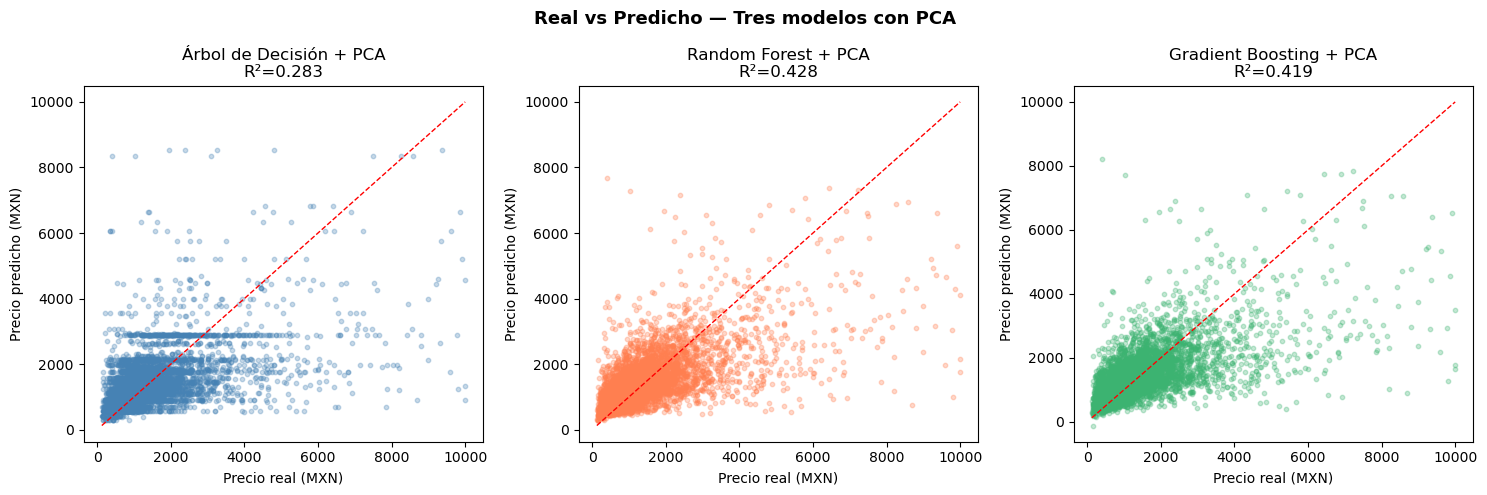

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    (y_pred_tree_pca, r2_tree_pca, 'steelblue', 'Árbol de Decisión'),
    (y_pred_rf_pca,   r2_rf_pca,   'coral',     'Random Forest'),
    (y_pred_gb_pca,   r2_gb_pca,   'mediumseagreen', 'Gradient Boosting'),
]
for ax, (y_pred, r2, color, name) in zip(axes, configs):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
    ax.set_xlabel('Precio real (MXN)')
    ax.set_ylabel('Precio predicho (MXN)')
    ax.set_title(f'{name} + PCA\nR²={r2:.3f}')
plt.suptitle('Real vs Predicho — Tres modelos con PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Comparación completa de reducción de dimensionalidad

Comparamos todas las estrategias: variables originales, selección por correlación, selección por importancia y PCA — aplicadas a los tres algoritmos.

In [46]:
resultados_dim_completo = pd.DataFrame({
    'Modelo': [
        'Árbol — original',
        'RF — original',
        'GB — original',
        'RF — 5 por importancia',
        'RF — 5 por correlación',
        f'Árbol — PCA ({n_componentes_80} comp.)',
        f'RF — PCA ({n_componentes_80} comp.)',
        f'GB — PCA ({n_componentes_80} comp.)',
    ],
    'R²':         [r2_tree,      r2_rf,      r2_gb,
                   r2_imp,        r2_corr,
                   r2_tree_pca,  r2_rf_pca,  r2_gb_pca],
    'MAE (MXN)':  [mae_tree,     mae_rf,     mae_gb,
                   mae_imp,       mae_corr,
                   mae_tree_pca, mae_rf_pca, mae_gb_pca],
    'RMSE (MXN)': [rmse_tree,    rmse_rf,    rmse_gb,
                   rmse_imp,      rmse_corr,
                   rmse_tree_pca,rmse_rf_pca,rmse_gb_pca],
})
resultados_dim_completo = resultados_dim_completo.sort_values('R²', ascending=False).reset_index(drop=True)
resultados_dim_completo.round(4)

,Modelo,R²,MAE (MXN),RMSE (MXN)
0,GB — original,0.5621,448.5403,760.0114
1,RF — original,0.5372,454.3677,781.2919
2,RF — 5 por importancia,0.4513,505.1569,850.7351
3,RF — PCA (10 comp.),0.4281,512.1796,868.4781
4,Árbol — original,0.4190,513.4283,875.3693
5,GB — PCA (10 comp.),0.4189,519.3007,875.4448
6,RF — 5 por correlación,0.3627,550.8785,916.8066
7,Árbol — PCA (10 comp.),0.2832,574.1093,972.3439


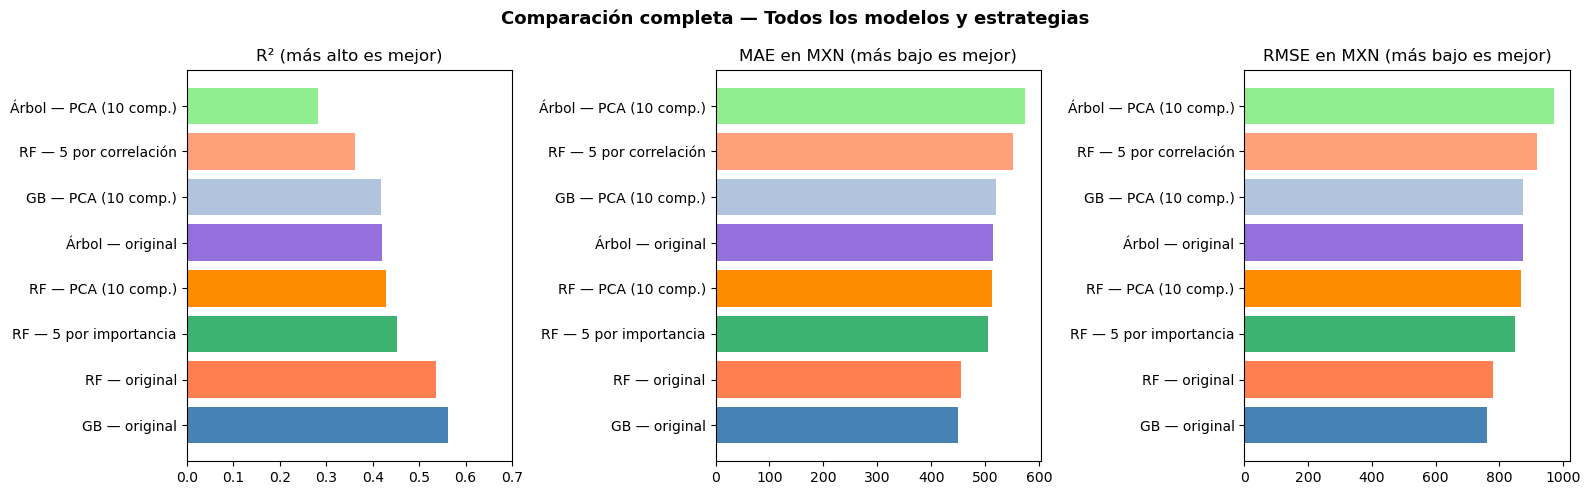

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_full = ['steelblue','coral','mediumseagreen',
                'darkorange','mediumpurple',
                'lightsteelblue','lightsalmon','lightgreen']

axes[0].barh(resultados_dim_completo['Modelo'], resultados_dim_completo['R²'], color=colores_full)
axes[0].set_title('R² (más alto es mejor)', fontsize=12)
axes[0].set_xlim(0, 0.7)

axes[1].barh(resultados_dim_completo['Modelo'], resultados_dim_completo['MAE (MXN)'], color=colores_full)
axes[1].set_title('MAE en MXN (más bajo es mejor)', fontsize=12)

axes[2].barh(resultados_dim_completo['Modelo'], resultados_dim_completo['RMSE (MXN)'], color=colores_full)
axes[2].set_title('RMSE en MXN (más bajo es mejor)', fontsize=12)

plt.suptitle('Comparación completa — Todos los modelos y estrategias', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 10. ¿Cuánto debería cobrar Gabriela?

Ahora usamos el mejor modelo para estimar el precio del departamento de Gabriela con sus características específicas:
- **Ubicación:** Coyoacán
- **Tipo de propiedad:** Entire rental unit
- **Tipo de espacio:** Entire home/apt
- **Habitaciones:** 2
- **Camas:** 2
- **Capacidad:** 4 personas
- **Baños:** 1
- **Amenidades incluidas:** Internet, TV, estacionamiento
- **Noches mínimas:** 2
- **Anfitrión nuevo (sin reseñas aún)**

In [48]:
# Recreamos el encoder sobre los valores originales de df (no df_model)
le_neighbourhood = LabelEncoder()
le_neighbourhood.fit(df['neighbourhood_cleansed'].astype(str))

le_room = LabelEncoder()
le_room.fit(df['room_type'].astype(str))

le_prop = LabelEncoder()
le_prop.fit(df['property_type'].astype(str))

coyoacan_code = le_neighbourhood.transform(['Coyoacán'])[0]
room_code     = le_room.transform(['Entire home/apt'])[0]
prop_code     = le_prop.transform(['Entire rental unit'])[0]

gabriela = {
    'neighbourhood_cleansed': coyoacan_code,
    'room_type':              room_code,
    'property_type':          prop_code,
    'accommodates':           4,
    'bedrooms':               2,
    'beds':                   2,
    'bathrooms':              1,
    'minimum_nights':         2,
    'host_is_superhost':      0,
    'host_identity_verified': 1,
    'instant_bookable':       0,
    'review_scores_rating':   df['review_scores_rating'].median(),
    'review_scores_cleanliness': df['review_scores_cleanliness'].median(),
    'review_scores_location': df['review_scores_location'].median(),
    'number_of_reviews':      0,
    'reviews_per_month':      0.0,
    'availability_365':       180,
    'calculated_host_listings_count': 1
}

df_gabriela = pd.DataFrame([gabriela])
df_gabriela

,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms,minimum_nights,host_is_superhost,host_identity_verified,instant_bookable,review_scores_rating,review_scores_cleanliness,review_scores_location,number_of_reviews,reviews_per_month,availability_365,calculated_host_listings_count
0,2,0,20,4,2,2,1,2,0,1,0,4.84,4.85,4.92,0,0.0,180,1


In [49]:
# Predicción con Gradient Boosting (mejor modelo)
precio_estimado = gb.predict(df_gabriela)[0]
print(f'Precio estimado para el departamento de Gabriela: ${precio_estimado:.2f} MXN por noche')
print(f'Rango estimado (± MAE del modelo): ${precio_estimado - mae_gb:.2f} — ${precio_estimado + mae_gb:.2f} MXN por noche')

Precio estimado para el departamento de Gabriela: $1375.52 MXN por noche
Rango estimado (± MAE del modelo): $926.98 — $1824.06 MXN por noche


Propiedades similares en Coyoacán (2 hab, departamento completo): 248
Precio mínimo:    $260.00 MXN
Precio mediano:   $1184.00 MXN
Precio promedio:  $1330.54 MXN
Precio máximo:    $6409.00 MXN

>>> Precio recomendado por el modelo: $1375.52 MXN/noche


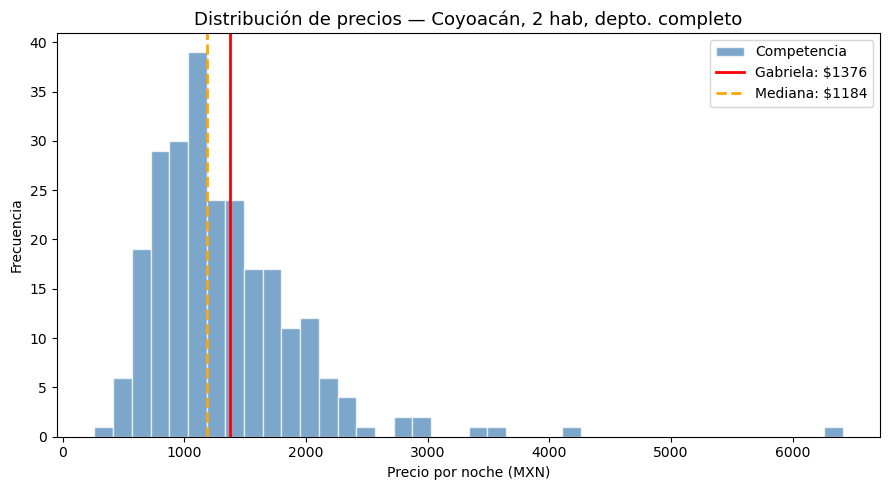

In [50]:
# Contexto: comparar con propiedades similares en Coyoacán
similares = df[(df['neighbourhood_cleansed'] == 'Coyoacán') &
               (df['bedrooms'] == 2) &
               (df['room_type'] == 'Entire home/apt')]

print(f'Propiedades similares en Coyoacán (2 hab, departamento completo): {len(similares)}')
print(f'Precio mínimo:    ${similares["price"].min():.2f} MXN')
print(f'Precio mediano:   ${similares["price"].median():.2f} MXN')
print(f'Precio promedio:  ${similares["price"].mean():.2f} MXN')
print(f'Precio máximo:    ${similares["price"].max():.2f} MXN')
print()
print(f'>>> Precio recomendado por el modelo: ${precio_estimado:.2f} MXN/noche')

plt.figure(figsize=(9, 5))
plt.hist(similares['price'], bins=40, color='steelblue', edgecolor='white', alpha=0.7, label='Competencia')
plt.axvline(precio_estimado, color='red', linewidth=2, label=f'Gabriela: ${precio_estimado:.0f}')
plt.axvline(similares['price'].median(), color='orange', linewidth=2, linestyle='--',
            label=f'Mediana: ${similares["price"].median():.0f}')
plt.title('Distribución de precios — Coyoacán, 2 hab, depto. completo', fontsize=13)
plt.xlabel('Precio por noche (MXN)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones

* El árbol de decisión es fácil de interpretar y visualizar, pero puede sobreajustarse si no se limita su profundidad.
* El Random Forest entrena muchos árboles distintos y promedia sus resultados, por eso generalmente tiene mejor R² y menor MAE.
* El Gradient Boosting construye los árboles de forma secuencial, donde cada árbol corrige los errores del anterior. Esto le permite capturar patrones más complejos y obtener el mejor desempeño de los tres.
* Según la Feature Importance del Random Forest, las variables más influyentes fueron el número de habitaciones (bedrooms con 25%), los baños (bathrooms con 18%) y el tipo de propiedad (property_type con 10%). La correlación también señala accommodates, bedrooms y bathrooms como las más relacionadas con el precio.
* La selección de variables (reducción de dimensionalidad) mostró que el modelo con las 5 variables de mayor Feature Importance obtuvo un R² de 0.45 vs 0.54 del modelo completo. Si bien hay una reducción en desempeño, confirma que pocas variables concentran la mayor parte de la información. Esto confirma que no todas las variables aportan igual, y que simplificar el modelo puede ser una buena estrategia.
* La reducción con PCA (10 componentes, 83.9% de varianza retenida) mostró que su impacto varía según el algoritmo: el Gradient Boosting mantiene un R² de 0.42 con PCA, mientras que el Árbol de Decisión cae a 0.28. Esto indica que los modelos de ensamble son más robustes a la transformación del espacio de variables que los árboles simples. En todos los casos, el modelo con variables originales supera al modelo con PCA.
* Para el departamento de Gabriela en Coyoacán (2 habitaciones, internet, TV y estacionamiento), el modelo estima un precio competitivo de \\$1,376 MXN por noche (rango: \\$926.98 — \\$1824.06 MXN según el MAE del modelo), lo cual es consistente con el mercado real de propiedades similares en la zona (mediana: \\$1,184 MXN).
* Se recomienda a Gabriela iniciar en el rango mediano del mercado y ajustar el precio conforme acumule reseñas positivas, ya que el historial de calificaciones es un factor que puede incrementar el precio potencial.